Exploration of the scenarios for the post-event GM prediction method.   
Only applicable for observed data, does not support simulations.

In [1]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sim_ranking as sr
import spatial_hazard as sh

sns.set_theme(style="white")

In [2]:
# Disable FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
# Config
# nzgmdb_ffp = Path("/Users/claudy/dev/work/data/gm_datasets/nz_gmdb/v3.0/Tables/ground_motion_im_table_rotd50_flat.csv")
# nzgmdb_ffp = Path("/Users/claudy/dev/work/data/gm_datasets/nz_gmdb/v3.3/Tables/ground_motion_im_table_rotd50_flat.csv")
# nzgmdb_ffp = Path("/Users/claudy/dev/work/data/gm_datasets/nz_gmdb/v3.4/Tables/ground_motion_im_table_rotd50_flat.csv")
nzgmdb_ffp = Path("/Users/claudy/dev/work/data/gm_datasets/nz_gmdb/v4.2/custom/mod_ground_motion_im_table_rotd50_flat.csv")

**NZGMDB version:** `{python} str(nzgmdb_ffp.parent.parent.name)`

In [12]:
### Data loading
obs_data = sr.data.load_obs_nzgmdb(nzgmdb_ffp)
print(f"Number of records: {obs_data.n_records}")

events, all_sites = obs_data.events, obs_data.sites
event_sites = obs_data.event_sites
print(f"Number of events: {len(events)}")
print(f"Number of sites: {len(all_sites)}")
print(f"Number of records: {obs_data.n_records}")

Number of records: 70159
Number of events: 3708
Number of sites: 383
Number of records: 70159


## Valid SOI selection
### Selection of SOI using observed PGA

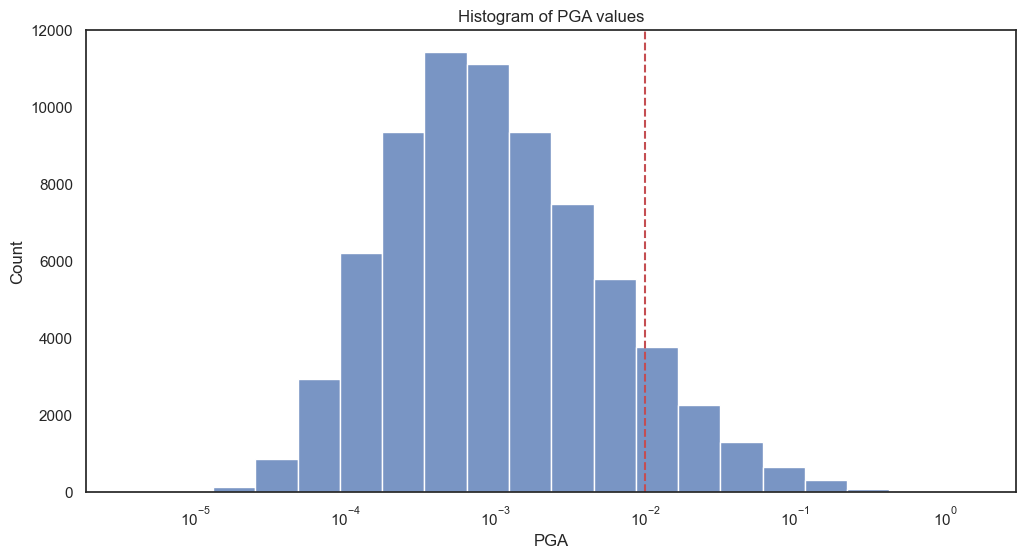

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(obs_data.record_df.PGA, bins=20, ax=ax, log_scale=(True, False))
ax.axvline(0.01, color='r', linestyle='--')
ax.set_title("Histogram of PGA values");

In [6]:
pga_threshold = 0.01
cur_record_df = obs_data.record_df[obs_data.record_df.PGA > pga_threshold]

Select the records with PGA values greater than a threshold value of `{python} print(pga_threshold)`.  
Number of records selected: `{python} print(len(cur_record_df))`. 

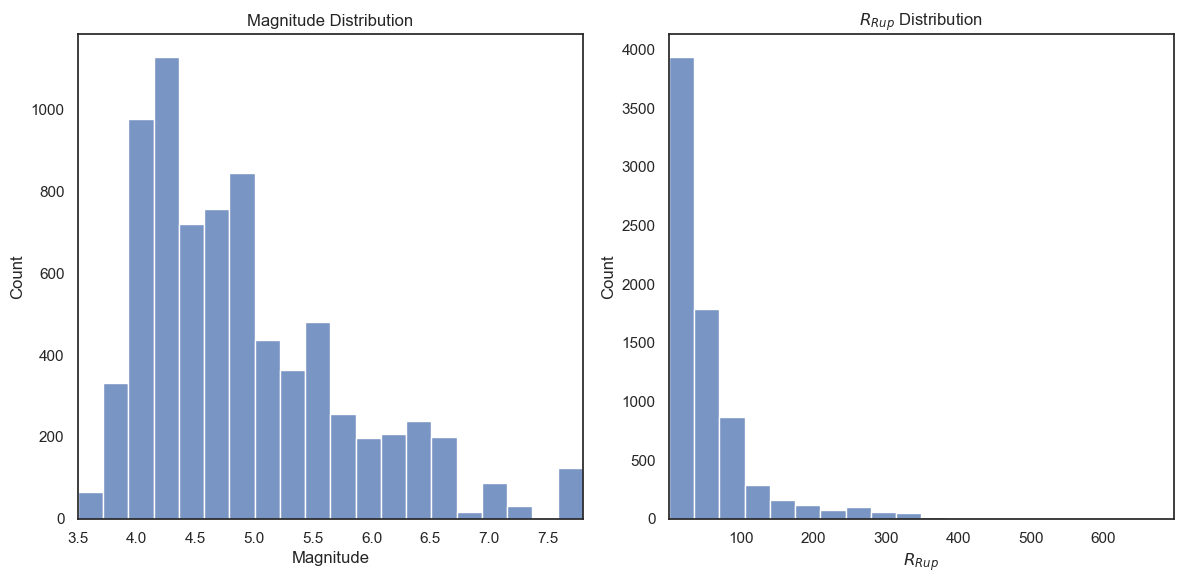

In [7]:
# Plot magnitude & distance distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(cur_record_df["mag"], bins=20, ax=ax1)
ax1.set_title("Magnitude Distribution")
ax1.set_xlabel("Magnitude")
ax1.set_xlim(cur_record_df["mag"].min(), cur_record_df["mag"].max())

sns.histplot(cur_record_df["rrup"], bins=20, ax=ax2)
ax2.set_title("$R_{Rup}$ Distribution")
ax2.set_xlabel("$R_{Rup}$")
ax2.set_xlim(cur_record_df["rrup"].min(), cur_record_df["rrup"].max())

fig.tight_layout()


### Valid site calculation using GMM
Only consider records that would experience shaking PGA > 0.01g for a magnitude 6 event, based on the Bradley 2013 GMPE.

In [13]:
# Get the set of valid site-interests per event
print(f"Getting valid sites of interest")
valid_int_sites, valid_event_int_sites, valid_record_ids = sr.ml.data.get_valid_site_ints(
    obs_data.event_sites, obs_data.record_df.drop(columns=obs_data.ims)
)
cur_record_df = obs_data.record_df.loc[valid_record_ids]

Getting valid sites of interest
Valid SOI records: 57792/70159


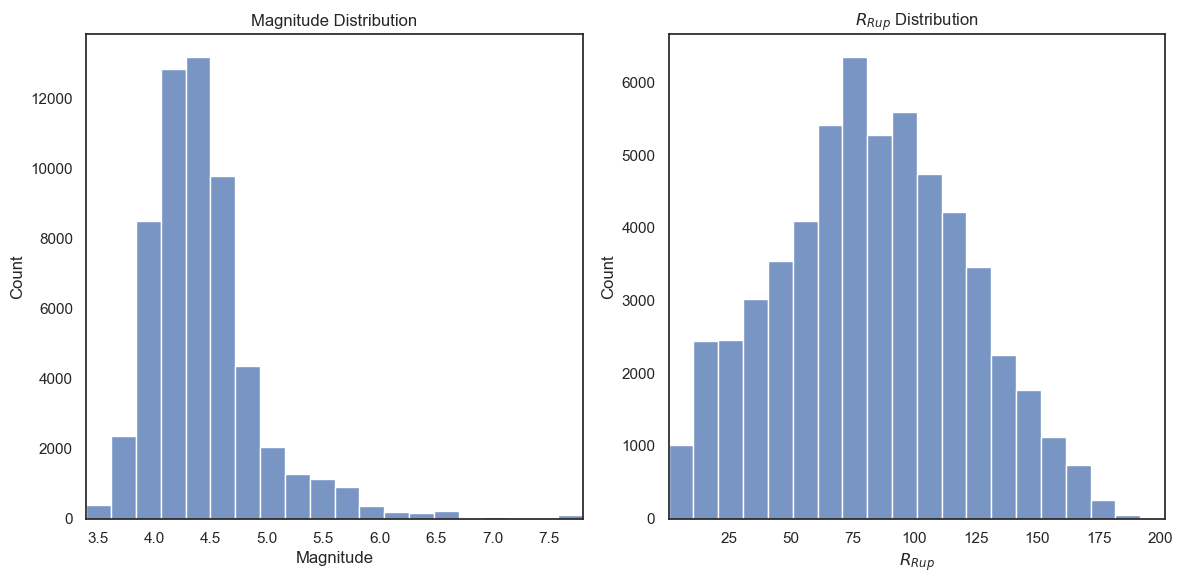

In [14]:
# Plot magnitude & distance distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(cur_record_df["mag"], bins=20, ax=ax1)
ax1.set_title("Magnitude Distribution")
ax1.set_xlabel("Magnitude")
ax1.set_xlim(cur_record_df["mag"].min(), cur_record_df["mag"].max())

sns.histplot(cur_record_df["rrup"], bins=20, ax=ax2)
ax2.set_title("$R_{Rup}$ Distribution")
ax2.set_xlabel("$R_{Rup}$")
ax2.set_xlim(cur_record_df["rrup"].min(), cur_record_df["rrup"].max())

fig.tight_layout()


## Scenario Computation


In [15]:
def run_scenario_computation(max_dist: int, closest_max_dist: int, max_n_obs_sites: int, min_n_obs_sites: int):
    # Compute potential scenarios
    dist_matrix = sr.utils.calculate_distance_matrix(all_sites, obs_data.site_df)
    lb_corr_data = sr.LBSiteCorrelationData.from_dist_matrix(dist_matrix, sr.constants.PSA_KEYS)
    
    valid_events = list(valid_event_int_sites.keys())
    event_site_combs, used_event_sites = sr.ml.data.compute_site_combinations(
            event_sites,
            valid_event_int_sites,
            valid_events,
            dist_matrix,
            obs_data.sites,
            obs_data.sites,
            max_dist=max_dist,
            closest_max_dist=closest_max_dist,
            max_n_obs_sites=max_n_obs_sites,
            min_n_obs_sites=min_n_obs_sites,
        )
    
    # Get scenario df
    scenario_df = sr.ml.utils.create_scenario_df(event_site_combs, event_sites, obs_data, dist_matrix=dist_matrix, lb_corr_data=lb_corr_data)
    
    print(f"Number of events: {scenario_df.event.nunique()}")
    print(f"Number of scenarios: {scenario_df.shape[0]}")
    
    # Plot number of observations sites & degree of constraint distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    sns.histplot(scenario_df.n_obs_sites, bins=20, ax=ax1)
    ax1.set_title("Number of observation sites")
    ax1.set_xlabel("Number of observation sites")
    ax1.set_xlim(0, scenario_df.n_obs_sites.max())
    
    sns.histplot(scenario_df.constraintness, bins=20, ax=ax2)
    ax2.set_title("Degree of constraint")
    ax2.set_xlabel("Degree of constraint")
    ax2.set_xlim(0, scenario_df.constraintness.max())
    
    fig.tight_layout()
    
    # Number of observations vs rrup
    g = sns.jointplot(data=scenario_df, x="rrup", y="constraintness", kind="hex", marginal_kws=dict(bins=20), height=8, joint_kws=dict(gridsize=40), )
    
    # Number of observations vs mag
    g = sns.jointplot(data=scenario_df, x="mag", y="constraintness", kind="hex", marginal_kws=dict(bins=20), height=8, joint_kws=dict(gridsize=40), )

### Max-distance: 10

Number of events: 1278
Number of scenarios: 26584


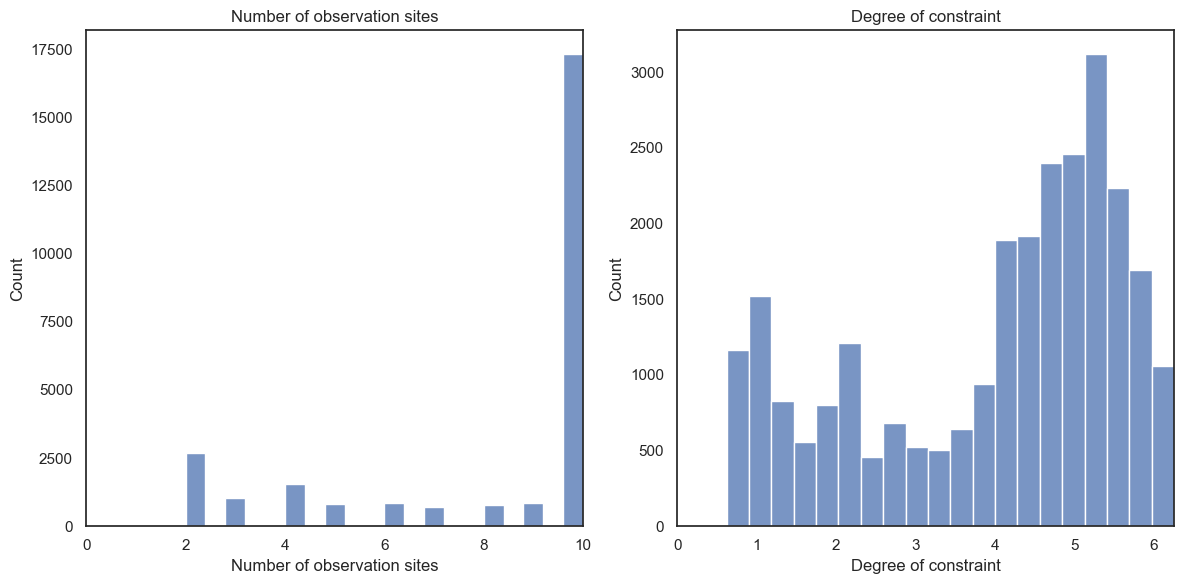

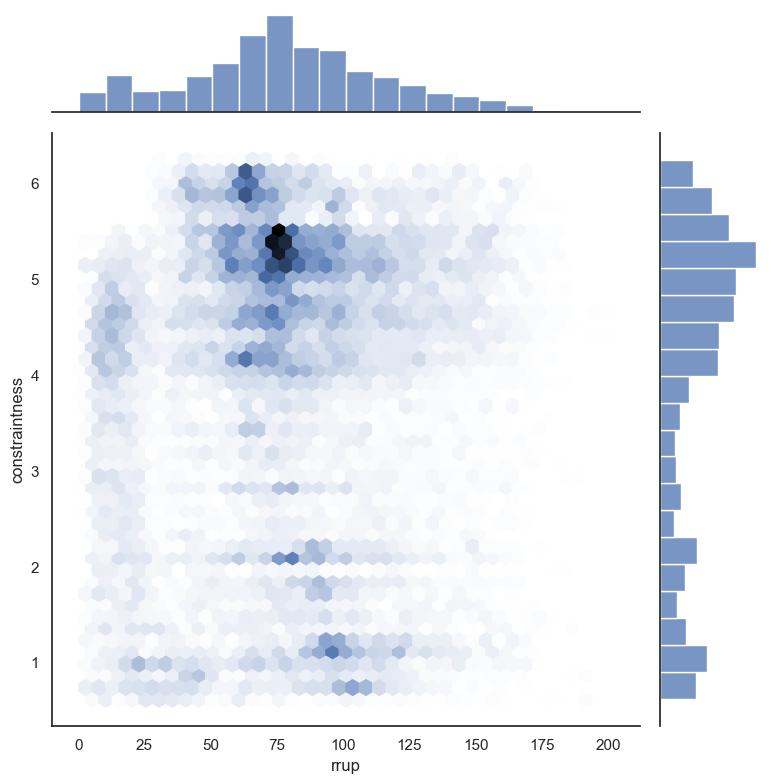

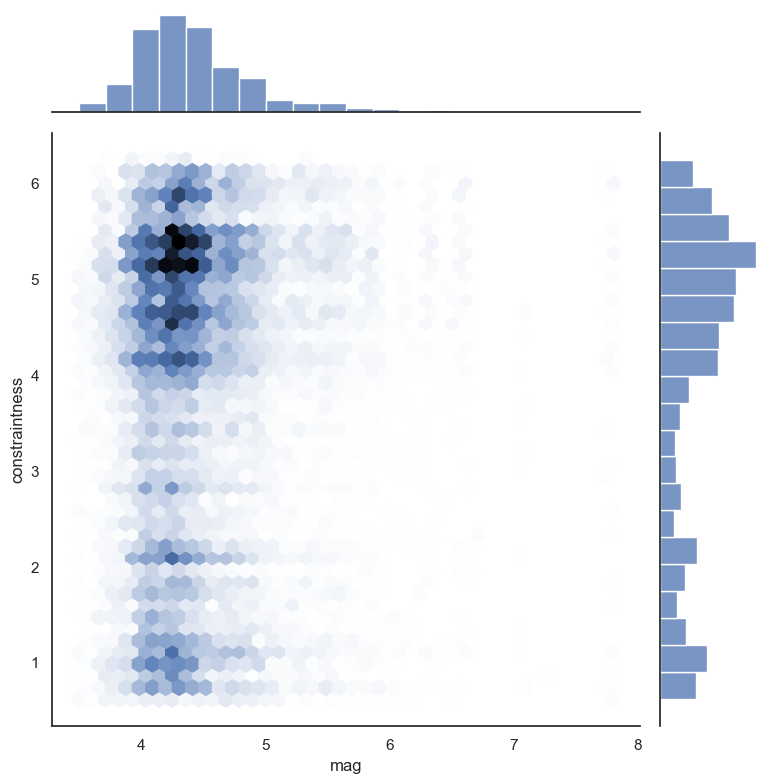

In [16]:
run_scenario_computation(10, 10, 10, 2)

### Max-distance: 15

In [ ]:
run_scenario_computation(15, 10, 10, 2)

### Max-distance: 20

In [ ]:
run_scenario_computation(20, 10, 10, 2)

### Max-distance: 30

In [ ]:
run_scenario_computation(30, 10, 10, 2)

### Effect of $F_{min}$ Filtering (max-dist: 15)

In [18]:
# Compute potential scenarios
dist_matrix = sh.im_dist.calculate_distance_matrix(all_sites, obs_data.site_df)
lb_corr_data = sr.LBSiteCorrelationData.from_dist_matrix(dist_matrix, sr.constants.PSA_KEYS)

valid_events = list(valid_event_int_sites.keys())
event_site_combs, used_event_sites = sr.ml.data.compute_site_combinations(
        event_sites,
        valid_event_int_sites,
        valid_events,
        dist_matrix,
        obs_data.sites,
        obs_data.sites,
        max_dist=30,
        closest_max_dist=10,
        max_n_obs_sites=10,
        min_n_obs_sites=2,
    )

# Get scenario df
scenario_df = sr.ml.utils.create_scenario_df(event_site_combs, event_sites, obs_data, dist_matrix=dist_matrix, lb_corr_data=lb_corr_data)

print(f"Number of events: {scenario_df.event.nunique()}")
print(f"Number of scenarios: {scenario_df.shape[0]}")

Number of events: 1531
Number of scenarios: 31183


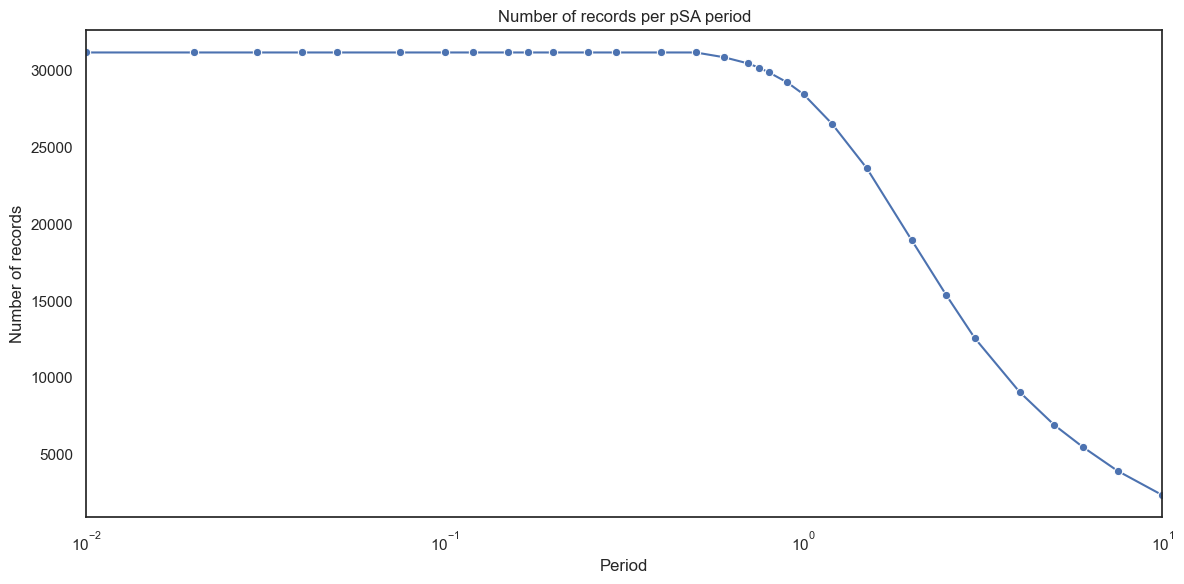

In [19]:
# Compute the number of scenarios per pSA period
n_im_records = pd.Series({float(cur_pSA.split("_")[1]): np.sum(~np.isnan(obs_data.record_df.loc[scenario_df.index, cur_pSA]))  for cur_pSA in sr.constants.PSA_KEYS})

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(x=sr.constants.PERIODS, y=n_im_records.values, ax=ax, marker="o")

ax.set_title("Number of records per pSA period")
ax.set_xlabel("Period")
ax.set_ylabel("Number of records")
ax.set_xscale("log")
ax.set_xlim(0.01, 10)

fig.tight_layout()
